<a href="https://colab.research.google.com/github/Nour-Yasser/LogisticRegressionEx/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

In [25]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

class LogisticRegression():

    def __init__(self,lr=0.001,n_iters=1000, optimizer='batch', batch_size = 32):
        self.lr=lr
        self.n_iters=n_iters
        self.weights = None
        self.bias = None
        self.optimizer = optimizer
        self.losses = []
        self.batch_size = batch_size

    def fit(self,X,y):
        n_samples,n_features=X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.losses = []

        if self.optimizer == 'batch':
          self.batch_gradient_descent(X,y)
        elif self.optimizer == 'stochastic':
          self.stochastic_gradient_descent(X,y)
        elif self.optimizer == 'minibatch':
          self.minibatch_gradient_descent(X,y)
        else:
          raise ValueError("Invalid optimizer. Choose from 'batch', 'stochastic', or 'minibatch'.")

    def batch_gradient_descent(self,X,y):

        n_samples,n_features=X.shape

        for i in range(self.n_iters):

            linear_predictions=np.dot(X,self.weights)+self.bias
            predictions=sigmoid(linear_predictions)

            dw=(1/n_samples)*np.dot(X.T,(predictions-y))
            db=(1/n_samples)*np.sum(predictions-y)

            self.weights-=self.lr*dw
            self.bias-=self.lr*db

            loss = - (1 / n_samples) * np.sum(y * np.log(predictions + 1e-10) + (1 - y) * np.log(1 - predictions + 1e-10))
            self.losses.append(loss)


    def stochastic_gradient_descent(self, X, y):
        """
        Implements the Stochastic Gradient Descent (SGD) optimization algorithm.

        Parameters:
        X (numpy.ndarray): The training data features.
        y (numpy.ndarray): The training data labels.
        """
        n_samples = X.shape[0]
        for i in range(self.n_iters):
            for idx in range(n_samples):
                # Get a single training example
                xi = X[idx, :]
                yi = y[idx]

                # Calculate prediction
                linear_prediction = np.dot(xi, self.weights) + self.bias
                prediction = sigmoid(linear_prediction)

                # Compute gradients
                dw = np.dot(xi.reshape(-1, 1), (prediction - yi).reshape(1, 1))
                db = prediction - yi

                # Update parameters
                self.weights -= self.lr * dw.flatten()
                self.bias -= self.lr * db
            # Calculate loss after each epoch for comparison.  This is NOT typical of SGD.
            linear_predictions_epoch = np.dot(X, self.weights) + self.bias
            predictions_epoch = sigmoid(linear_predictions_epoch)
            loss = - (1 / n_samples) * np.sum(y * np.log(predictions_epoch + 1e-10) + (1 - y) * np.log(1 - predictions_epoch + 1e-10))
            self.losses.append(loss)


    def minibatch_gradient_descent(self, X, y):
        """
        Implements the Mini-Batch Gradient Descent optimization algorithm.

        Parameters:
        X (numpy.ndarray): The training data features.
        y (numpy.ndarray): The training data labels.
        """
        n_samples = X.shape[0]
        num_batches = n_samples // self.batch_size  # Integer division to get number of full batches
        if n_samples % self.batch_size != 0:
            num_batches += 1 # Add one more batch for the remaining samples

        for i in range(self.n_iters):
            # Shuffle the data at the beginning of each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for batch_idx in range(num_batches):
                # Get the current mini-batch
                start_idx = batch_idx * self.batch_size
                end_idx = min((batch_idx + 1) * self.batch_size, n_samples)  # Handle the last batch
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]
                batch_size = len(X_batch) # Number of samples in the current batch

                # Calculate predictions for the mini-batch
                linear_predictions = np.dot(X_batch, self.weights) + self.bias
                predictions = sigmoid(linear_predictions)

                # Compute gradients
                dw = (1 / batch_size) * np.dot(X_batch.T, (predictions - y_batch))
                db = (1 / batch_size) * np.sum(predictions - y_batch)

                # Update parameters
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
            # Calculate loss after each epoch
            linear_predictions_epoch = np.dot(X, self.weights) + self.bias
            predictions_epoch = sigmoid(linear_predictions_epoch)
            loss = - (1 / n_samples) * np.sum(y * np.log(predictions_epoch + 1e-10) + (1 - y) * np.log(1 - predictions_epoch + 1e-10))
            self.losses.append(loss)


    def predict(self,X):
            linear_predictions=np.dot(X,self.weights)+self.bias
            y_pred = sigmoid(linear_predictions)
            class_preds = [0 if y<=0.5 else 1 for y in y_pred]
            return class_preds




In [26]:
#synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model using Batch Gradient Descent
model = LogisticRegression(lr=0.01, n_iters=1000, optimizer='batch')
model.fit(X_train, y_train)

# Define the optimizers to use
optimizers = ['batch', 'stochastic', 'minibatch']


Training with Batch Gradient Descent:
Batch Descent Metrics:
Accuracy: 0.8700
Precision: 0.9355
Recall: 0.8131
F1 Score: 0.8700
Confusion Matrix:
 [[87  6]
 [20 87]]
[np.float64(0.6931471803599453), np.float64(0.6892853015257129), np.float64(0.6854853945206566), np.float64(0.681746393287276), np.float64(0.6780672399119491), np.float64(0.674446885349796), np.float64(0.6708842900994725), np.float64(0.6673784248285256), np.float64(0.6639282709501488), np.float64(0.6605328211523359), np.float64(0.6571910798805854), np.float64(0.6539020637754485), np.float64(0.6506648020663138), np.float64(0.6474783369229377), np.float64(0.6443417237662901), np.float64(0.6412540315403618), np.float64(0.638214342946625), np.float64(0.635221754642867), np.float64(0.6322753774081463), np.float64(0.6293743362756231), np.float64(0.6265177706350165), np.float64(0.623704834306427), np.float64(0.6209346955872459), np.float64(0.6182065372738379), np.float64(0.6155195566596535), np.float64(0.6128729655113867), np.fl

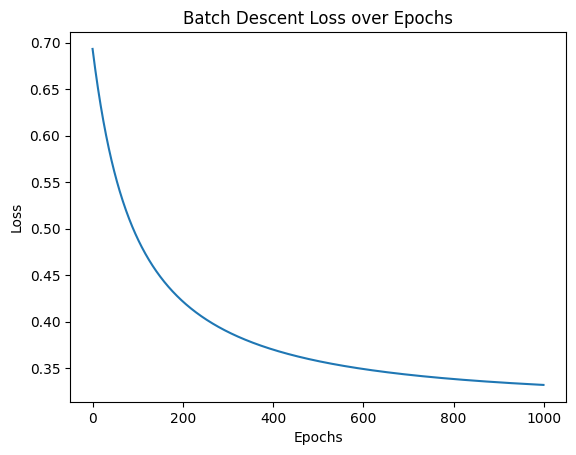


Training with Stochastic Gradient Descent:
Stochastic Descent Metrics:
Accuracy: 0.8650
Precision: 0.9167
Recall: 0.8224
F1 Score: 0.8670
Confusion Matrix:
 [[85  8]
 [19 88]]
[np.float64(0.3372370896249565), np.float64(0.32325555359778646), np.float64(0.32013706316252527), np.float64(0.3192339766816614), np.float64(0.3189581490786417), np.float64(0.318882148382641), np.float64(0.31887080996289363), np.float64(0.31887843173014035), np.float64(0.318889568747156), np.float64(0.31889944903971773), np.float64(0.318907034673985), np.float64(0.31891249376839453), np.float64(0.31891629042408703), np.float64(0.31891887945109), np.float64(0.31892062411202693), np.float64(0.3189217911345842), np.float64(0.3189225681380771), np.float64(0.31892308393371765), np.float64(0.3189234256844534), np.float64(0.31892365184508614), np.float64(0.3189238013972946), np.float64(0.31892390024378847), np.float64(0.3189239655572312), np.float64(0.31892400870599324), np.float64(0.3189240372090541), np.float64(0.31

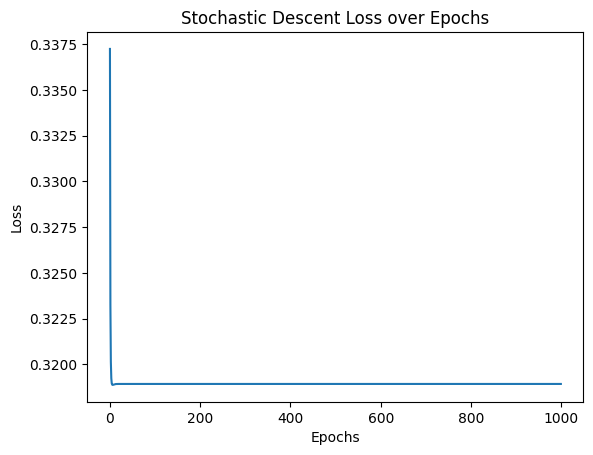


Training with Minibatch Gradient Descent:
Minibatch Descent Metrics:
Accuracy: 0.8550
Precision: 0.9149
Recall: 0.8037
F1 Score: 0.8557
Confusion Matrix:
 [[85  8]
 [21 86]]
[np.float64(0.6125820702130061), np.float64(0.5576453129843456), np.float64(0.518309245751671), np.float64(0.48896391577537074), np.float64(0.46637401960064184), np.float64(0.4483840021462841), np.float64(0.43380340063929806), np.float64(0.42176551430824233), np.float64(0.4116300400196448), np.float64(0.40298397563026844), np.float64(0.3955524067603642), np.float64(0.3891046596833019), np.float64(0.383438376555406), np.float64(0.37845297736950856), np.float64(0.37401033099166225), np.float64(0.3700460883359824), np.float64(0.36649666138887216), np.float64(0.3632846723347653), np.float64(0.36037653242191253), np.float64(0.35773517108410063), np.float64(0.35532837982392307), np.float64(0.353122413044389), np.float64(0.3510990155141448), np.float64(0.3492337065711321), np.float64(0.34751213444956464), np.float64(0.34

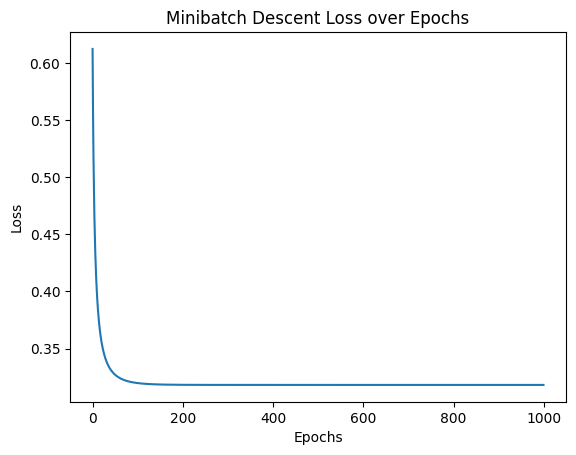

In [29]:
# Loop through each optimizer
for optimizer_choice in optimizers:
    print(f"\nTraining with {optimizer_choice.capitalize()} Gradient Descent:")
    model = LogisticRegression(lr=0.01, n_iters=1000, optimizer=optimizer_choice, batch_size=32)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    cm = confusion_matrix(y_test, predictions)

    print(f"{optimizer_choice.capitalize()} Descent Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", cm)

    print(model.losses)

    # Plot the loss curve
    plt.plot(np.squeeze(model.losses))
    plt.title(f'{optimizer_choice.capitalize()} Descent Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()